## IMPORTING DEPENDENCIES

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,KFold,RandomizedSearchCV
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_squared_error,r2_score
import joblib

In [ ]:
# Convertind food time delivery csv file dataframe
data = pd.read_csv('Data/train.csv')

In [9]:
data.head(2)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33


In [10]:
data.shape

(45593, 20)

## Data Cleaning :

### -> Filling Missing values and Removing Noise

In [11]:
data['Weatherconditions'].value_counts()

Weatherconditions
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64

In [12]:
data['Weatherconditions'] = data['Weatherconditions'].apply(lambda x:np.nan if x == 'conditions NaN' else x)

In [13]:
data['Weatherconditions'].value_counts()

Weatherconditions
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
Name: count, dtype: int64

In [14]:
data['Weatherconditions'].isna().sum()

np.int64(616)

In [15]:
data['Weatherconditions'] = data['Weatherconditions'].fillna(data['Weatherconditions'].mode()[0])

In [16]:
data['Weatherconditions'].value_counts()

Weatherconditions
conditions Fog           8270
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
Name: count, dtype: int64

In [17]:
data['Road_traffic_density'].value_counts()

Road_traffic_density
Low        15477
Jam        14143
Medium     10947
High        4425
NaN          601
Name: count, dtype: int64

In [18]:
data['Road_traffic_density'] = data['Road_traffic_density'].apply(lambda x:x.replace(" ",""))

In [19]:
data['Road_traffic_density'] = data['Road_traffic_density'].apply(lambda x: np.nan if x == 'NaN'else x)

In [20]:
data['Road_traffic_density'].value_counts()

Road_traffic_density
Low       15477
Jam       14143
Medium    10947
High       4425
Name: count, dtype: int64

In [21]:
data['Road_traffic_density'].isna().sum()

np.int64(601)

In [22]:
data['Road_traffic_density'].fillna(data['Road_traffic_density'].mode(),inplace=True)

In [23]:
data['Road_traffic_density'].isna().sum()

np.int64(601)

In [24]:
data['Delivery_person_Age'].value_counts()

Delivery_person_Age
35      2262
36      2260
37      2227
30      2226
38      2219
24      2210
32      2202
22      2196
29      2191
33      2187
28      2179
25      2174
34      2166
26      2159
21      2153
27      2150
39      2144
20      2136
31      2120
23      2087
NaN     1854
50        53
15        38
Name: count, dtype: int64

In [25]:
data['Delivery_person_Age'].unique()

array(['37', '34', '23', '38', '32', '22', '33', '35', '36', '21', '24',
       '29', '25', '31', '27', '26', '20', 'NaN ', '28', '39', '30', '15',
       '50'], dtype=object)

In [26]:
# Converting string into number and removing NaN
data['Delivery_person_Age'] = data['Delivery_person_Age'].apply(lambda x:np.nan if x=='NaN ' else int(x))

In [27]:
data['Delivery_person_Age'].isna().sum()

np.int64(1854)

In [28]:
data['Delivery_person_Age'].fillna(data['Delivery_person_Age'].median(),inplace=True)

In [29]:
data['Delivery_person_Age'].isna().sum()

np.int64(0)

In [30]:
data['Delivery_person_Age'] = data['Delivery_person_Age'].apply(lambda x: int(x))

In [31]:
data['Delivery_person_Ratings'] = data['Delivery_person_Ratings'].apply(lambda x:np.nan if x == 'NaN ' else float(x))

In [32]:
data['Delivery_person_Ratings'].isna().sum()

np.int64(1908)

In [33]:
data['Delivery_person_Ratings'].fillna(data['Delivery_person_Ratings'].median(),inplace=True)

In [34]:
data['multiple_deliveries'].unique()

array(['0', '1', '3', 'NaN ', '2'], dtype=object)

In [35]:
data['multiple_deliveries'] = data['multiple_deliveries'].apply(lambda x:np.nan if x == 'NaN ' else int(x))

In [36]:
data['multiple_deliveries'].unique()

array([ 0.,  1.,  3., nan,  2.])

In [37]:
data['multiple_deliveries'].isna().sum()

np.int64(993)

In [38]:
data['multiple_deliveries'].fillna(data['multiple_deliveries'].median(),inplace=True)

In [39]:
data['multiple_deliveries'].isna().sum()

np.int64(0)

In [40]:
data['multiple_deliveries'] = data['multiple_deliveries'].apply(lambda x:int(x))

In [41]:
data['multiple_deliveries'].unique()

array([0, 1, 3, 2])

In [42]:
def remove_min(st):
    nums = ['0','1','2','3','4','5','6','7','8','9']
    for letter in st:
        if letter not in nums:
            st = st.replace(letter,"")
    return int(st)

In [43]:
data['Time_taken(min)'] = data['Time_taken(min)'].apply(remove_min)

In [44]:
data['Time_taken(min)'].unique()

array([24, 33, 26, 21, 30, 40, 32, 34, 46, 23, 20, 41, 15, 36, 39, 18, 38,
       47, 12, 22, 25, 35, 10, 19, 11, 28, 52, 16, 27, 49, 17, 14, 37, 44,
       42, 31, 13, 29, 50, 43, 48, 54, 53, 45, 51])

In [45]:
data['City'].unique()

array(['Urban ', 'Metropolitian ', 'Semi-Urban ', 'NaN '], dtype=object)

In [46]:
def remove_space1(st):
    for letter in st:
        if letter == " ":
            st = st.replace(" ","")
    if st == 'NaN':
        return np.nan
    else:
        return st
data['City'] = data['City'].apply(remove_space1)

In [47]:
data['City'].isna().sum()

np.int64(1200)

In [48]:
data['City'].fillna(data['City'].mode()[0],inplace=True)

In [49]:
data['City'].isna().sum()

np.int64(0)

In [50]:
data['Type_of_order'].unique()

array(['Snack ', 'Drinks ', 'Buffet ', 'Meal '], dtype=object)

In [51]:
data['Type_of_order'] = data['Type_of_order'].apply(lambda x:x.replace(" ",""))

In [52]:
data['Festival'].unique()

array(['No ', 'Yes ', 'NaN '], dtype=object)

In [53]:
data['Festival'] = data['Festival'].apply(lambda x:np.nan if x == 'NaN ' else x.replace(" ",""))

In [54]:
data['Festival'].unique()

array(['No', 'Yes', nan], dtype=object)

In [55]:
data['Festival'].isna().sum()

np.int64(228)

In [56]:
data['Festival'].fillna(data['Festival'].mode(),inplace=True)

In [57]:
data['Festival'].isna().sum()

np.int64(228)

In [58]:
data['Type_of_vehicle'].unique()

array(['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle '],
      dtype=object)

In [59]:
data['Type_of_vehicle'] = data['Type_of_vehicle'].apply(lambda x:x.replace(" ",""))

In [60]:
data['Type_of_vehicle'].unique()

array(['motorcycle', 'scooter', 'electric_scooter', 'bicycle'],
      dtype=object)

In [61]:
data['Time_Orderd'] = data["Time_Orderd"].apply(lambda x:np.nan if x == "NaN " else x)

In [62]:
data["Time_Orderd"].isna().sum()

np.int64(1731)

In [63]:
data["Time_Orderd"] = pd.to_datetime(data['Time_Orderd'],errors='coerce')

In [64]:
data['Order_Hour'] = data['Time_Orderd'].dt.hour
data['Order_minute'] = data['Time_Orderd'].dt.minute
data['Order_second'] = data['Time_Orderd'].dt.second

In [65]:
data['Order_Hour'].fillna(data['Order_Hour'].median(),inplace=True)
data['Order_minute'].fillna(data['Order_minute'].median(),inplace=True)
data['Order_second'].fillna(data['Order_second'].median(),inplace=True)

In [66]:
data['Order_Hour'] = data['Order_Hour'].apply(lambda x:int(x))
data['Order_second'] = data['Order_second'].apply(lambda x:int(x))
data['Order_minute'] = data['Order_minute'].apply(lambda x:int(x))

In [67]:
data = data.drop(columns=['Time_Orderd'],axis=1)

In [68]:
data.head(3)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Order_picked,...,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Order_Hour,Order_minute,Order_second
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:45:00,...,2,Snack,motorcycle,0,No,Urban,24,11,30,0
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:50:00,...,2,Snack,scooter,1,No,Metropolitian,33,19,45,0
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:45:00,...,0,Drinks,motorcycle,1,No,Urban,26,8,30,0


## Visualizing Categorical Data

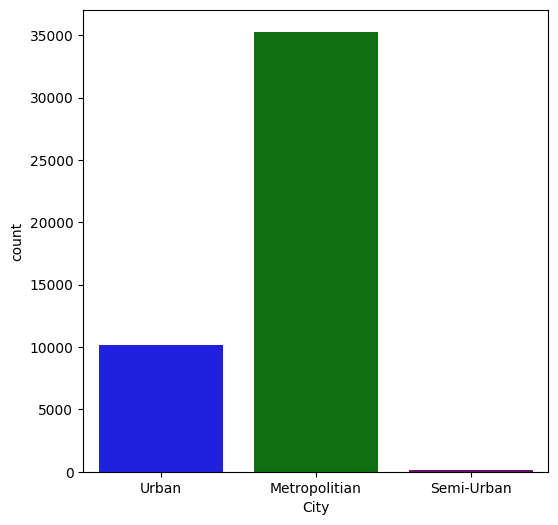

In [69]:
plt.figure(figsize=(6,6))
sns.countplot(x='City',data=data,palette = ['blue','green','purple'])
plt.show()

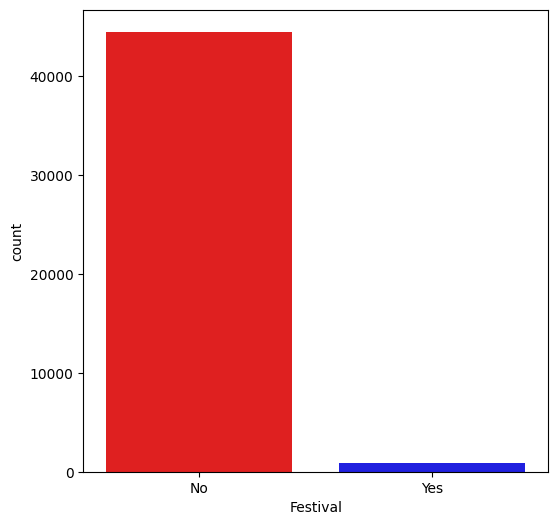

In [70]:
plt.figure(figsize=(6,6))
sns.countplot(x='Festival',data=data,palette=['red','blue'])
plt.show()

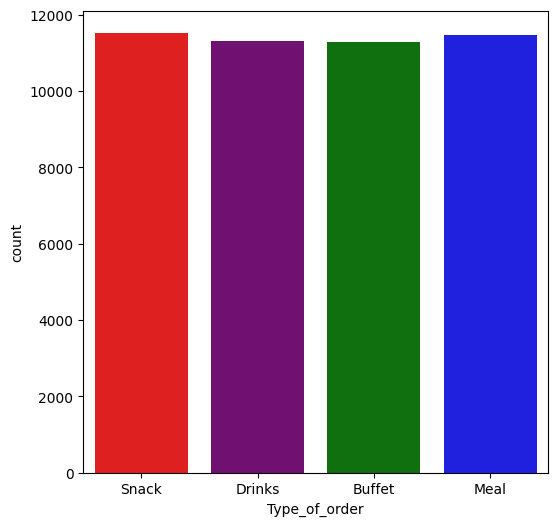

In [71]:
plt.figure(figsize=(6,6))
sns.countplot(x='Type_of_order',data=data,palette=['red','purple','green','blue'])
plt.show()

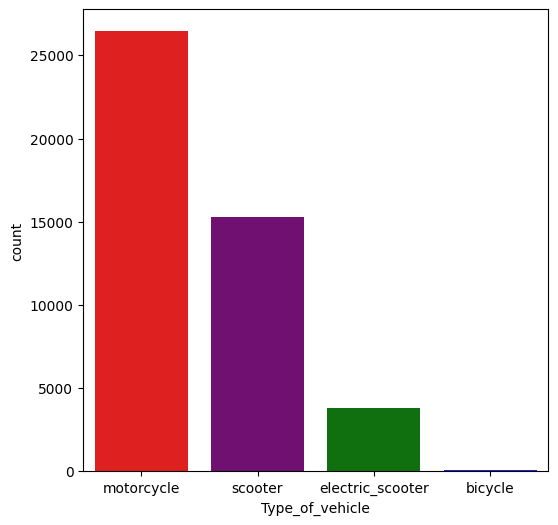

In [72]:
plt.figure(figsize=(6,6))
sns.countplot(x='Type_of_vehicle',data=data,palette=['red','purple','green','blue'])
plt.show()

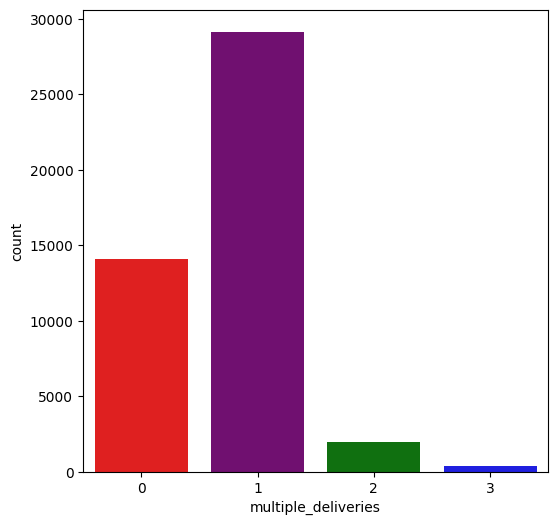

In [73]:
plt.figure(figsize=(6,6))
sns.countplot(x='multiple_deliveries',data=data,palette=['red','purple','green','blue'])
plt.show()

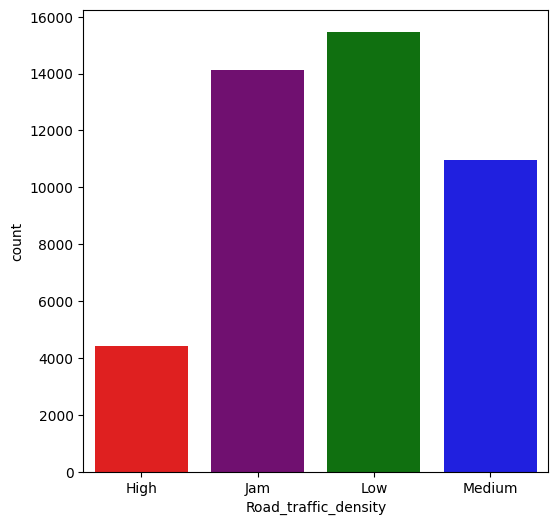

In [74]:
plt.figure(figsize=(6,6))
sns.countplot(x='Road_traffic_density',data=data,palette=['red','purple','green','blue'])
plt.show()

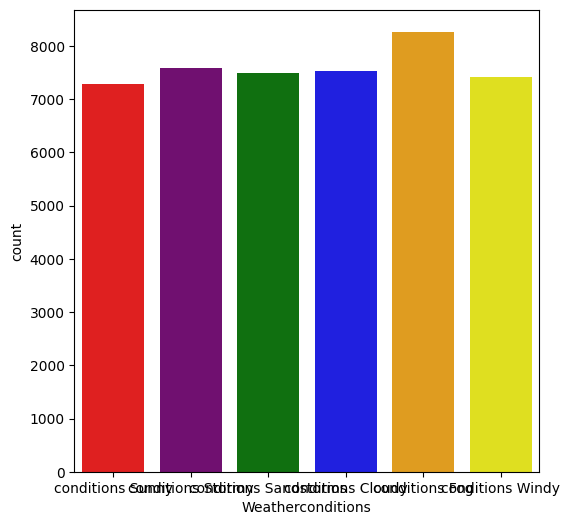

In [75]:
plt.figure(figsize=(6,6))
sns.countplot(x='Weatherconditions',data=data,palette=['red','purple','green','blue','orange','yellow'])
plt.show()

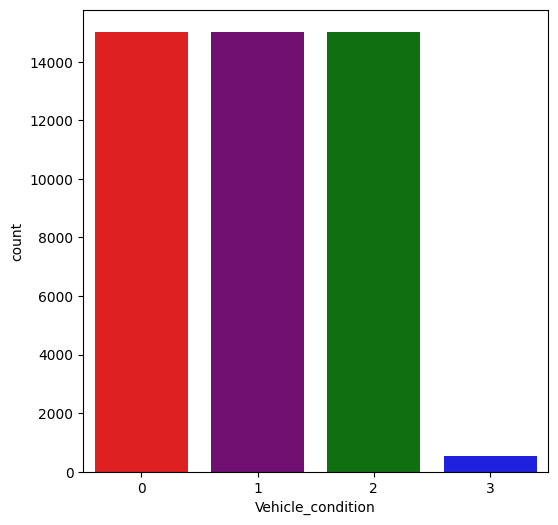

In [76]:
plt.figure(figsize=(6,6))
sns.countplot(x='Vehicle_condition',data=data,palette=['red','purple','green','blue','orange','yellow'])
plt.show()

## Feature Engineering

In [77]:
# Convert String format into Datetime format
data['Time_Order_picked'] = pd.to_datetime(data['Time_Order_picked'])

In [78]:
data['Picked_hour'] = data['Time_Order_picked'].dt.hour
data['Picked_minute'] = data['Time_Order_picked'].dt.minute
data['Picked_second'] = data['Time_Order_picked'].dt.second

In [79]:
data = data.drop(columns=['ID','Delivery_person_ID'],axis=1)

In [80]:
data['Order_Date'].unique()

array(['19-03-2022', '25-03-2022', '05-04-2022', '26-03-2022',
       '11-03-2022', '04-03-2022', '14-03-2022', '20-03-2022',
       '12-02-2022', '13-02-2022', '14-02-2022', '02-04-2022',
       '01-03-2022', '16-03-2022', '15-02-2022', '10-03-2022',
       '27-03-2022', '12-03-2022', '01-04-2022', '05-03-2022',
       '11-02-2022', '08-03-2022', '03-04-2022', '30-03-2022',
       '28-03-2022', '18-03-2022', '06-04-2022', '04-04-2022',
       '24-03-2022', '09-03-2022', '02-03-2022', '13-03-2022',
       '29-03-2022', '31-03-2022', '17-03-2022', '07-03-2022',
       '15-03-2022', '16-02-2022', '03-03-2022', '18-02-2022',
       '23-03-2022', '17-02-2022', '06-03-2022', '21-03-2022'],
      dtype=object)

In [81]:
# Converting String format into Datetime format
data['Order_Date'] = pd.to_datetime(data['Order_Date'])

In [82]:
data['Order_day'] = data['Order_Date'].dt.day
data['Order_month'] = data['Order_Date'].dt.month
data['Order_year'] = data['Order_Date'].dt.year

In [83]:
data.drop(columns=['Order_Date','Time_Order_picked'],axis=1,inplace=True)

In [84]:
data.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,...,Time_taken(min),Order_Hour,Order_minute,Order_second,Picked_hour,Picked_minute,Picked_second,Order_day,Order_month,Order_year
0,37,4.9,22.745049,75.892471,22.765049,75.912471,conditions Sunny,High,2,Snack,...,24,11,30,0,11,45,0,19,3,2022
1,34,4.5,12.913041,77.683237,13.043041,77.813237,conditions Stormy,Jam,2,Snack,...,33,19,45,0,19,50,0,25,3,2022


## Data Preproccessing :

### A. Categorical Data -> Numerical Data

In [85]:
# Converting Odinal Data into Numeric Data
encoder = LabelEncoder()

data['Road_traffic_density'] = encoder.fit_transform(data['Road_traffic_density'])

data['Festival'] = encoder.fit_transform(data['Festival'])

In [86]:
# Converting Nominal data into Numeric data
encoder1 = OneHotEncoder(sparse_output=False,handle_unknown="ignore")

encoded_columns = encoder1.fit_transform(data[['Type_of_order','Weatherconditions','Type_of_vehicle','City']])

In [87]:
col = encoder1.get_feature_names_out()
print(col)

['Type_of_order_Buffet' 'Type_of_order_Drinks' 'Type_of_order_Meal'
 'Type_of_order_Snack' 'Weatherconditions_conditions Cloudy'
 'Weatherconditions_conditions Fog'
 'Weatherconditions_conditions Sandstorms'
 'Weatherconditions_conditions Stormy'
 'Weatherconditions_conditions Sunny' 'Weatherconditions_conditions Windy'
 'Type_of_vehicle_bicycle' 'Type_of_vehicle_electric_scooter'
 'Type_of_vehicle_motorcycle' 'Type_of_vehicle_scooter'
 'City_Metropolitian' 'City_Semi-Urban' 'City_Urban']


In [88]:
encoded_data = pd.DataFrame(encoded_columns,columns=encoder1.get_feature_names_out())

In [89]:
encoded_data.head(2)

,Type_of_order_Buffet,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Weatherconditions_conditions Cloudy,Weatherconditions_conditions Fog,Weatherconditions_conditions Sandstorms,Weatherconditions_conditions Stormy,Weatherconditions_conditions Sunny,Weatherconditions_conditions Windy,Type_of_vehicle_bicycle,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,City_Metropolitian,City_Semi-Urban,City_Urban
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [90]:
data = data.drop(columns=["City","Type_of_vehicle","Weatherconditions","Type_of_order"])
data = pd.concat([data,encoded_data],axis=1)

In [91]:
data.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Road_traffic_density,Vehicle_condition,multiple_deliveries,Festival,...,Weatherconditions_conditions Stormy,Weatherconditions_conditions Sunny,Weatherconditions_conditions Windy,Type_of_vehicle_bicycle,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,City_Metropolitian,City_Semi-Urban,City_Urban
0,37,4.9,22.745049,75.892471,22.765049,75.912471,0,2,0,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,34,4.5,12.913041,77.683237,13.043041,77.813237,1,2,1,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


## Visualizing Distribution of Data

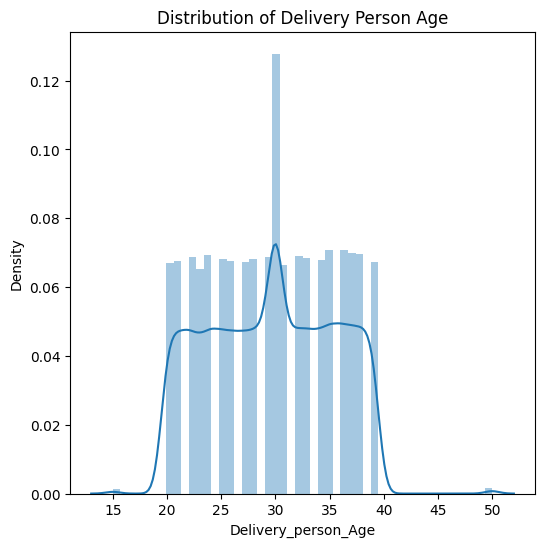

In [92]:
plt.figure(figsize=(6,6))
sns.distplot(data['Delivery_person_Age'])
plt.title("Distribution of Delivery Person Age")
plt.show()

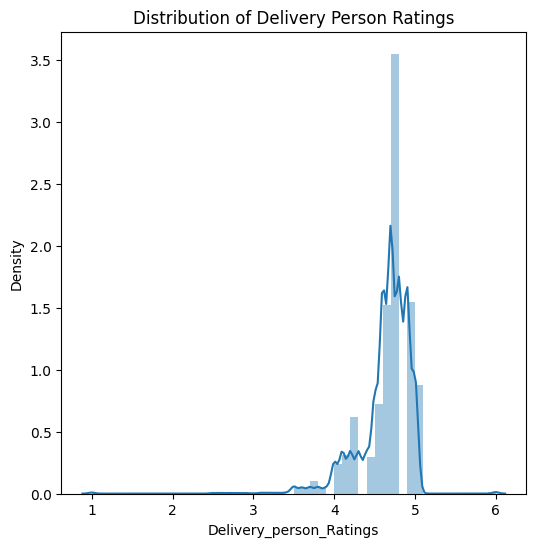

In [93]:
plt.figure(figsize=(6,6))
sns.distplot(data['Delivery_person_Ratings'])
plt.title("Distribution of Delivery Person Ratings")
plt.show()

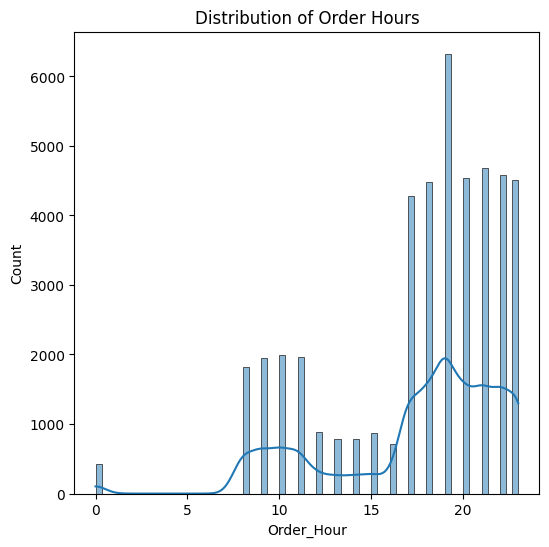

In [94]:
plt.figure(figsize=(6,6))
sns.histplot(data['Order_Hour'],kde=True)
plt.title("Distribution of Order Hours")
plt.show()

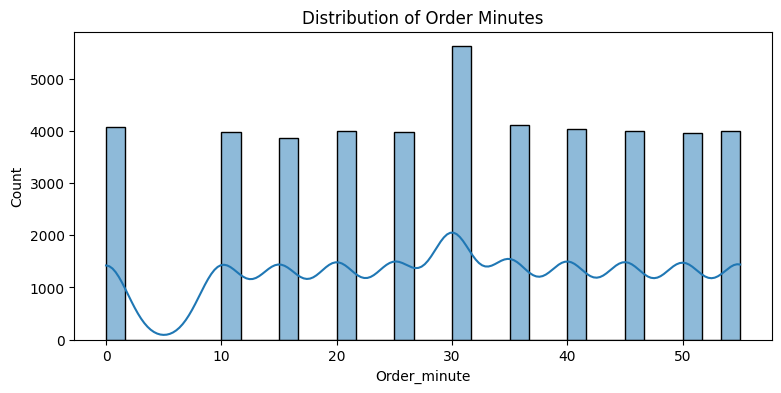

In [95]:
plt.figure(figsize=(9,4))
sns.histplot(data['Order_minute'],kde=True)
plt.title("Distribution of Order Minutes")
plt.show()

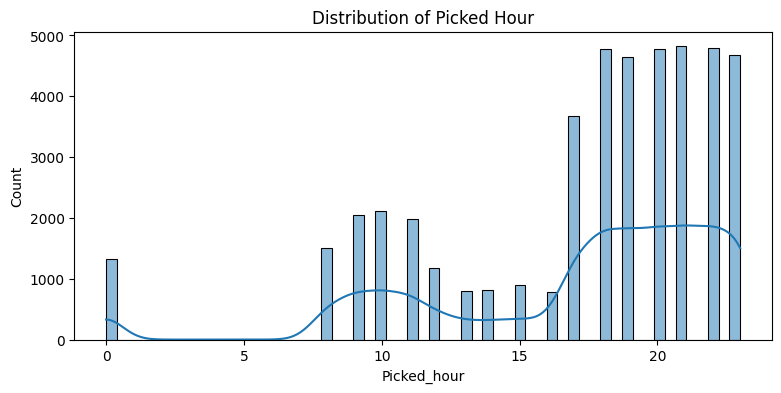

In [96]:
plt.figure(figsize=(9,4))
sns.histplot(data['Picked_hour'],kde=True)
plt.title("Distribution of Picked Hour")
plt.show()

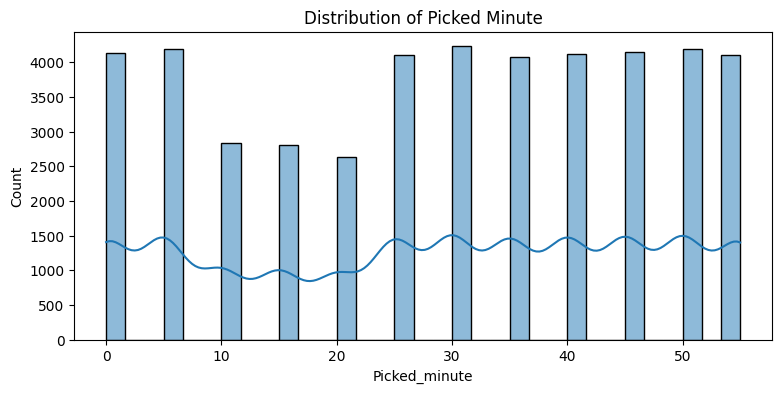

In [97]:
plt.figure(figsize=(9,4))
sns.histplot(data['Picked_minute'],kde=True)
plt.title("Distribution of Picked Minute")
plt.show()

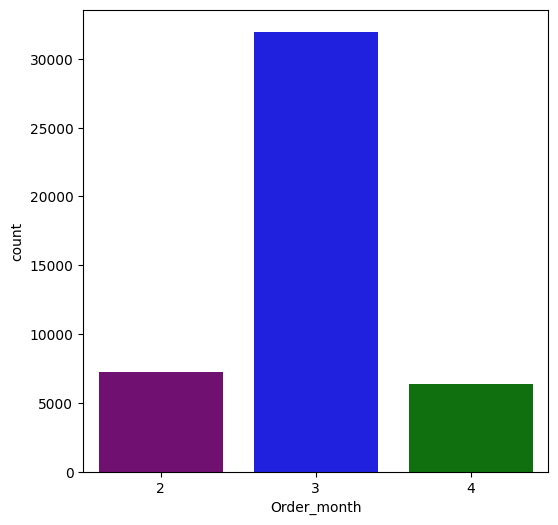

In [98]:
plt.figure(figsize=(6,6))
sns.countplot(x='Order_month',data=data,palette=['purple','blue','green'])
plt.show()

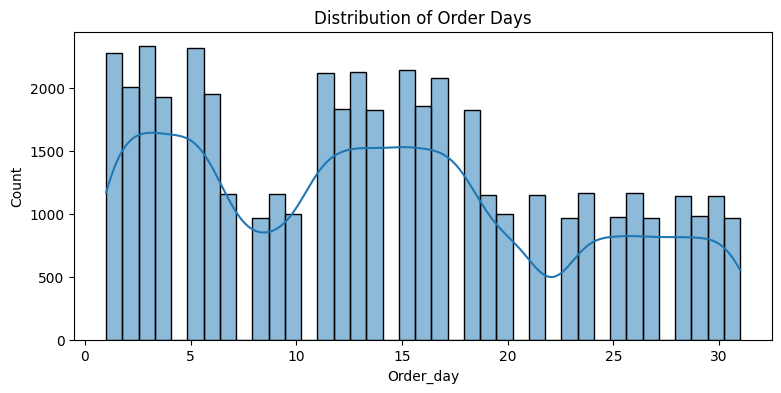

In [99]:
plt.figure(figsize = (9,4))
sns.histplot(data['Order_day'],kde=True)
plt.title("Distribution of Order Days")
plt.show()

### B. Spliting data into training and testing sets

In [100]:
x = data.drop(columns=['Time_taken(min)'],axis=1)
y = data['Time_taken(min)']

In [101]:
# Spliting data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

### C. Standarizing Data

In [102]:
std = StandardScaler()
x_std = std.fit_transform(x_train[['Delivery_person_Age',
           'Delivery_person_Ratings',
           'multiple_deliveries',
           'Restaurant_latitude',
           'Restaurant_longitude',
           'Delivery_location_latitude',
           'Delivery_location_longitude',
           'Vehicle_condition',
           'Order_Hour',
           'Order_minute',
           'Order_second',
           'Order_month',
           'Order_year',
           'Order_day',
           'Picked_hour',
           'Picked_minute',
           'Picked_second']])

x_std1 = std.transform(x_test[['Delivery_person_Age',
           'Delivery_person_Ratings',
           'multiple_deliveries',
           'Restaurant_latitude',
           'Restaurant_longitude',
           'Delivery_location_latitude',
           'Delivery_location_longitude',
           'Vehicle_condition',
           'Order_Hour',
           'Order_minute',
           'Order_second',
           'Order_month',
           'Order_year',
           'Order_day',
           'Picked_hour',
           'Picked_minute',
           'Picked_second']])

In [103]:
# Converting Numpy Array into Dataframe
x_train1 = pd.DataFrame(x_std,columns = ['Delivery_person_Age',
           'Delivery_person_Ratings',
           'multiple_deliveries',
           'Restaurant_latitude',
           'Restaurant_longitude',
           'Delivery_location_latitude',
           'Delivery_location_longitude',
           'Vehicle_condition',
           'Order_Hour',
           'Order_minute',
           'Order_second',
           'Order_month',
           'Order_year',
           'Order_day',
           'Picked_hour',
           'Picked_minute',
           'Picked_second'])

x_test1 = pd.DataFrame(x_std1,columns= ['Delivery_person_Age',
           'Delivery_person_Ratings',
           'multiple_deliveries',
           'Restaurant_latitude',
           'Restaurant_longitude',
           'Delivery_location_latitude',
           'Delivery_location_longitude',
           'Vehicle_condition',
           'Order_Hour',
           'Order_minute',
           'Order_second',
           'Order_month',
           'Order_year',
           'Order_day',
           'Picked_hour',
           'Picked_minute',
           'Picked_second'])

In [104]:
x_train.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Road_traffic_density,Vehicle_condition,multiple_deliveries,Festival,...,Weatherconditions_conditions Stormy,Weatherconditions_conditions Sunny,Weatherconditions_conditions Windy,Type_of_vehicle_bicycle,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,City_Metropolitian,City_Semi-Urban,City_Urban
29044,37,4.8,22.308096,73.167753,22.318096,73.177753,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
41736,28,4.2,12.337978,76.616792,12.367978,76.646792,2,0,1,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [105]:
# Droping columns
x_train = x_train.drop(columns = ['Delivery_person_Age',
           'Delivery_person_Ratings',
           'multiple_deliveries',
           'Restaurant_latitude',
           'Restaurant_longitude',
           'Delivery_location_latitude',
           'Delivery_location_longitude',
           'Vehicle_condition',
           'Order_Hour',
           'Order_minute',
           'Order_second',
           'Order_month',
           'Order_year',
           'Order_day',
           'Picked_hour',
           'Picked_minute',
           'Picked_second'],axis = 1)

x_test = x_test.drop(columns = ['Delivery_person_Age',
           'Delivery_person_Ratings',
           'multiple_deliveries',
           'Restaurant_latitude',
           'Restaurant_longitude',
           'Delivery_location_latitude',
           'Delivery_location_longitude',
           'Vehicle_condition',
           'Order_Hour',
           'Order_minute',
           'Order_second',
           'Order_month',
           'Order_year',
           'Order_day',
           'Picked_hour',
           'Picked_minute',
           'Picked_second'],axis = 1)

In [106]:
x_train.head(2)

,Road_traffic_density,Festival,Type_of_order_Buffet,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Weatherconditions_conditions Cloudy,Weatherconditions_conditions Fog,Weatherconditions_conditions Sandstorms,Weatherconditions_conditions Stormy,Weatherconditions_conditions Sunny,Weatherconditions_conditions Windy,Type_of_vehicle_bicycle,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,City_Metropolitian,City_Semi-Urban,City_Urban
29044,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
41736,2,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [107]:
# Reseting Columns
x_train = x_train.reset_index(drop=True)
x_train1 = x_train1.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)
x_test1 = x_test1.reset_index(drop=True)

In [108]:
# Concating two dataframes
x_train = pd.concat([x_train,x_train1],axis=1)
x_test = pd.concat([x_test,x_test1],axis=1)

In [109]:
x_train.head(2)

,Road_traffic_density,Festival,Type_of_order_Buffet,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Weatherconditions_conditions Cloudy,Weatherconditions_conditions Fog,Weatherconditions_conditions Sandstorms,Weatherconditions_conditions Stormy,...,Vehicle_condition,Order_Hour,Order_minute,Order_second,Order_month,Order_year,Order_day,Picked_hour,Picked_minute,Picked_second
0,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-1.221336,-1.363145,-0.586487,0.0,0.037176,0.0,0.824427,-1.149798,0.079185,0.0
1,2,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-1.221336,0.958168,0.333869,0.0,0.037176,0.0,-1.474751,0.916813,1.217833,0.0


### Clustering Data

In [110]:
cluster = KMeans(n_clusters=3,random_state= 42)
cluster.fit(x_train[['Restaurant_latitude',
                          'Restaurant_longitude',
                          'Delivery_location_latitude',
                          'Delivery_location_longitude']])

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [111]:
x_train['cluster'] = cluster.predict(x_train[['Restaurant_latitude',
                          'Restaurant_longitude',
                          'Delivery_location_latitude',
                          'Delivery_location_longitude']])

In [112]:
x_train.head(2)

,Road_traffic_density,Festival,Type_of_order_Buffet,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Weatherconditions_conditions Cloudy,Weatherconditions_conditions Fog,Weatherconditions_conditions Sandstorms,Weatherconditions_conditions Stormy,...,Order_Hour,Order_minute,Order_second,Order_month,Order_year,Order_day,Picked_hour,Picked_minute,Picked_second,cluster
0,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-1.363145,-0.586487,0.0,0.037176,0.0,0.824427,-1.149798,0.079185,0.0,1
1,2,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.958168,0.333869,0.0,0.037176,0.0,-1.474751,0.916813,1.217833,0.0,0


In [113]:
x_test['cluster'] = cluster.predict(x_test[['Restaurant_latitude',
                          'Restaurant_longitude',
                          'Delivery_location_latitude',
                          'Delivery_location_longitude']])

In [114]:
x_test.head(2)

,Road_traffic_density,Festival,Type_of_order_Buffet,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Weatherconditions_conditions Cloudy,Weatherconditions_conditions Fog,Weatherconditions_conditions Sandstorms,Weatherconditions_conditions Stormy,...,Order_Hour,Order_minute,Order_second,Order_month,Order_year,Order_day,Picked_hour,Picked_minute,Picked_second,cluster
0,3,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.114054,-0.586487,0.0,0.037176,0.0,0.709468,0.165318,0.363847,0.0,1
1,1,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.325082,-1.200058,0.0,0.037176,0.0,1.974016,0.353192,-0.774802,0.0,1


## Model Selection

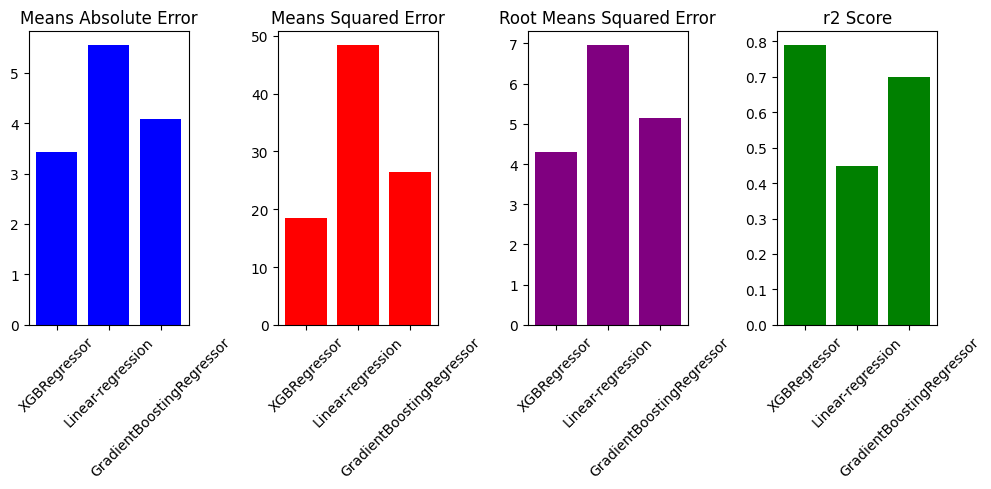

In [115]:
models = {"XGBRegressor":XGBRegressor(),
          "Linear-regression":LinearRegression(),
          "GradientBoostingRegressor":GradientBoostingRegressor()}

r2 = []
mae = []
rmse = []
mse = []

for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    mae.append(mean_absolute_error(y_test,y_pred))
    rmse.append(root_mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
    mse.append(mean_squared_error(y_test,y_pred))

# -------------------------------------------------------------

position = range(len(models))
model_names = list(models.keys())

fig,ax = plt.subplots(1,4,figsize=(10,5))

ax[0].bar(position,mae,color = "blue")
ax[0].set_title("Means Absolute Error")
ax[0].set_xticks(position)
ax[0].set_xticklabels(model_names,rotation = 45)

ax[1].bar(position,mse,color = "red")
ax[1].set_title("Means Squared Error")
ax[1].set_xticks(position)
ax[1].set_xticklabels(model_names,rotation = 45)

ax[2].bar(position,rmse,color = "purple")
ax[2].set_title("Root Means Squared Error")
ax[2].set_xticks(position)
ax[2].set_xticklabels(model_names,rotation = 45)

ax[3].bar(position,r2,color = "green")
ax[3].set_title("r2 Score")
ax[3].set_xticks(position)
ax[3].set_xticklabels(model_names,rotation = 45)

plt.tight_layout()
plt.show()

## Model Training

In [116]:
model = XGBRegressor()

# Hperparameter tunning
parameters = {"n_estimators":[100,200,300,400,500,600,700,800],
              "max_depth":[4,7,10],
              "learning_rate":[0.01,0.1,0.2],
              "min_child_weight":[1,2,3,4,5,6,7,8,9,10],
              "reg_alpha":[0.01,0.05,0.1],
              "reg_lambda":[1,2,3,4,5]}

CV = KFold(n_splits=3,random_state=42,shuffle=True)
model_cv = RandomizedSearchCV(model,
                              param_distributions=parameters,
                              n_iter=100
                              ,n_jobs=-1,
                              random_state=42,
                              cv=CV,
                              scoring='r2')

In [117]:
model_cv.fit(x_train,y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [4, 7, ...], 'min_child_weight': [1, 2, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,100
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## Model Evaluation

In [118]:
# Perdiction on training data
y_train_pred = model_cv.predict(x_train)

In [ ]:
mae1 = mean_absolute_error(y_train,y_train_pred)
rmse1 = root_mean_squared_error(y_train,y_train_pred)
r2_train = r2_score(y_train,y_train_pred)

print("Training Data:")
print("Mean Absolute Error:",mae1)
print("Root Mean Squared Error:",rmse1)
print("R2 Score:",r2_train)

Training Data:
Mean Absolute Error: 2.4190502166748047
Root Mean Squared Error: 3.1119883060455322
R2 Score: 0.8901334404945374


In [120]:
y_pred = model_cv.predict(x_test)

In [121]:
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("Testing data:")
print("Mean Absolute Error:",mae)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",r2)

Testing data:
Mean Absolute Error: 3.3545069694519043
Root Mean Squared Error: 4.200779914855957
R2 Score: 0.7987348437309265


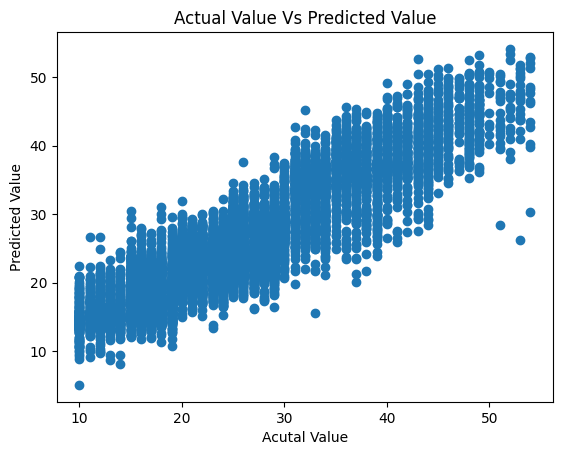

In [122]:
plt.scatter(y_test,y_pred)
plt.xlabel('Acutal Value')
plt.ylabel('Predicted Value')
plt.title('Actual Value Vs Predicted Value')
plt.show()

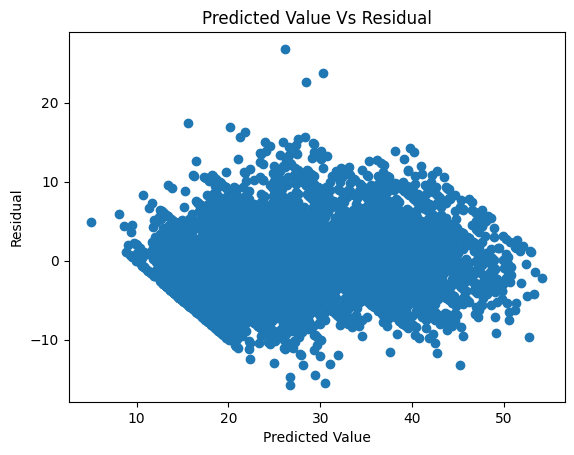

In [123]:
residual = y_test - y_pred

plt.scatter(y_pred,residual)
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.title('Predicted Value Vs Residual')
plt.show()

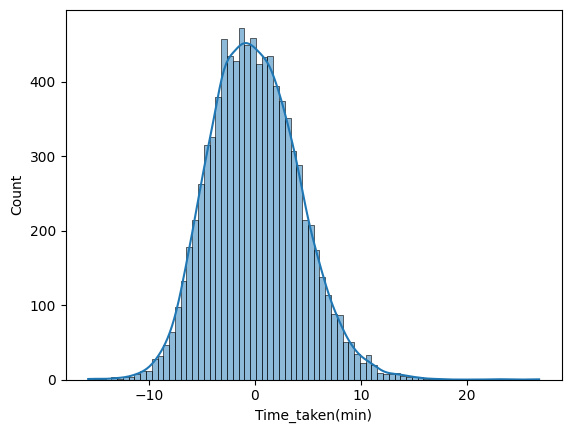

In [124]:
sns.histplot(residual,kde = True)
plt.show()